In [1]:
import json
from multiprocessing import Pool, cpu_count
from collections import defaultdict
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from tqdm import tqdm

In [ ]:
def murcko_train_val_test_split(
    smiles,
    n_val,
    n_test,
):

    def scaffold(smi):
        mol = Chem.MolFromSmiles(smi)
        return MurckoScaffold.MurckoScaffoldSmiles(mol=mol)

    scaffold_to_ids = defaultdict(list)
    scaffold_to_smiles = defaultdict(list)
    for i, smi in enumerate(smiles):
        scaffold_to_ids[scaffold(smi)].append(i)
        scaffold_to_smiles[scaffold(smi)].append(smi)

    # sort scaffolds by descending size (standard Murcko split)
    # groups = sorted(scaffold_to_ids.values(), key=len, reverse=True)
    groups = list(scaffold_to_ids.values())

    train, val, test = [], [], []
    train_scaffolds, val_scaffolds, test_scaffolds = [], [], []
    train_smiles, val_smiles, test_smiles = [], [], []

    for g in groups:
        if len(test) < n_test:
            test += g
            test_scaffolds += {scaffold(smiles[i]) for i in g}
            test_smiles += [smiles[i] for i in g]
        elif len(val) < n_val:
            val += g
            val_scaffolds += {scaffold(smiles[i]) for i in g}
            val_smiles += [smiles[i] for i in g]
        else:
            train += g
            train_scaffolds += {scaffold(smiles[i]) for i in g}
            train_smiles += [smiles[i] for i in g]
    return train, val, test, train_scaffolds, val_scaffolds, test_scaffolds, train_smiles, val_smiles, test_smiles, scaffold_to_smiles


In [57]:
new_drugs_summary_json = json.load(open("data/rdkit/new_summary_drugs.json", "r"))
smiles = list(new_drugs_summary_json.keys())
train, val, test, train_scaffolds, val_scaffolds, test_scaffolds, train_smiles, val_smiles, test_smiles, scaffold_to_smiles = murcko_train_val_test_split(smiles, 500, 1000)

In [ ]:
train_new_drugs_summary_json = {}
val_new_drugs_summary_json = {}
test_new_drugs_summary_json = {}

for i, (smi, data) in enumerate(new_drugs_summary_json.items()):
    if i in train:
        train_new_drugs_summary_json[smi] = data
    elif i in val:
        val_new_drugs_summary_json[smi] = data
    else:
        test_new_drugs_summary_json[smi] = data

assert len(train_new_drugs_summary_json) == len(train)
assert len(val_new_drugs_summary_json) == len(val)
assert len(test_new_drugs_summary_json) == len(test)

json.dump(train_new_drugs_summary_json, open("data/rdkit/train_new_summary_drugs.json", "w"), indent=4)
json.dump(val_new_drugs_summary_json, open("data/rdkit/val_new_summary_drugs.json", "w"), indent=4)
json.dump(test_new_drugs_summary_json, open("data/rdkit/test_new_summary_drugs.json", "w"), indent=4)


In [ ]:
from rdkit import Chem

import random

def draw_mols_from_smiles(smiles_list):
    # convert to mols
    mols = [Chem.MolFromSmiles(s) for s in smiles_list]

    # draw 6 columns → 4 rows automatically (24 mols)
    img = Draw.MolsToGridImage(
        mols,
        molsPerRow=6,
        subImgSize=(300, 300),   # size per molecule (px)
    )

    return img


In [59]:
random.seed(42)

train_smiles_sample = random.sample(train_smiles, 30)
test_smiles_sample = random.sample(test_smiles, 30)

train_scaffold_sample = random.sample(sorted(train_scaffolds), 30)
test_scaffold_sample = random.sample(sorted(test_scaffolds), 30)


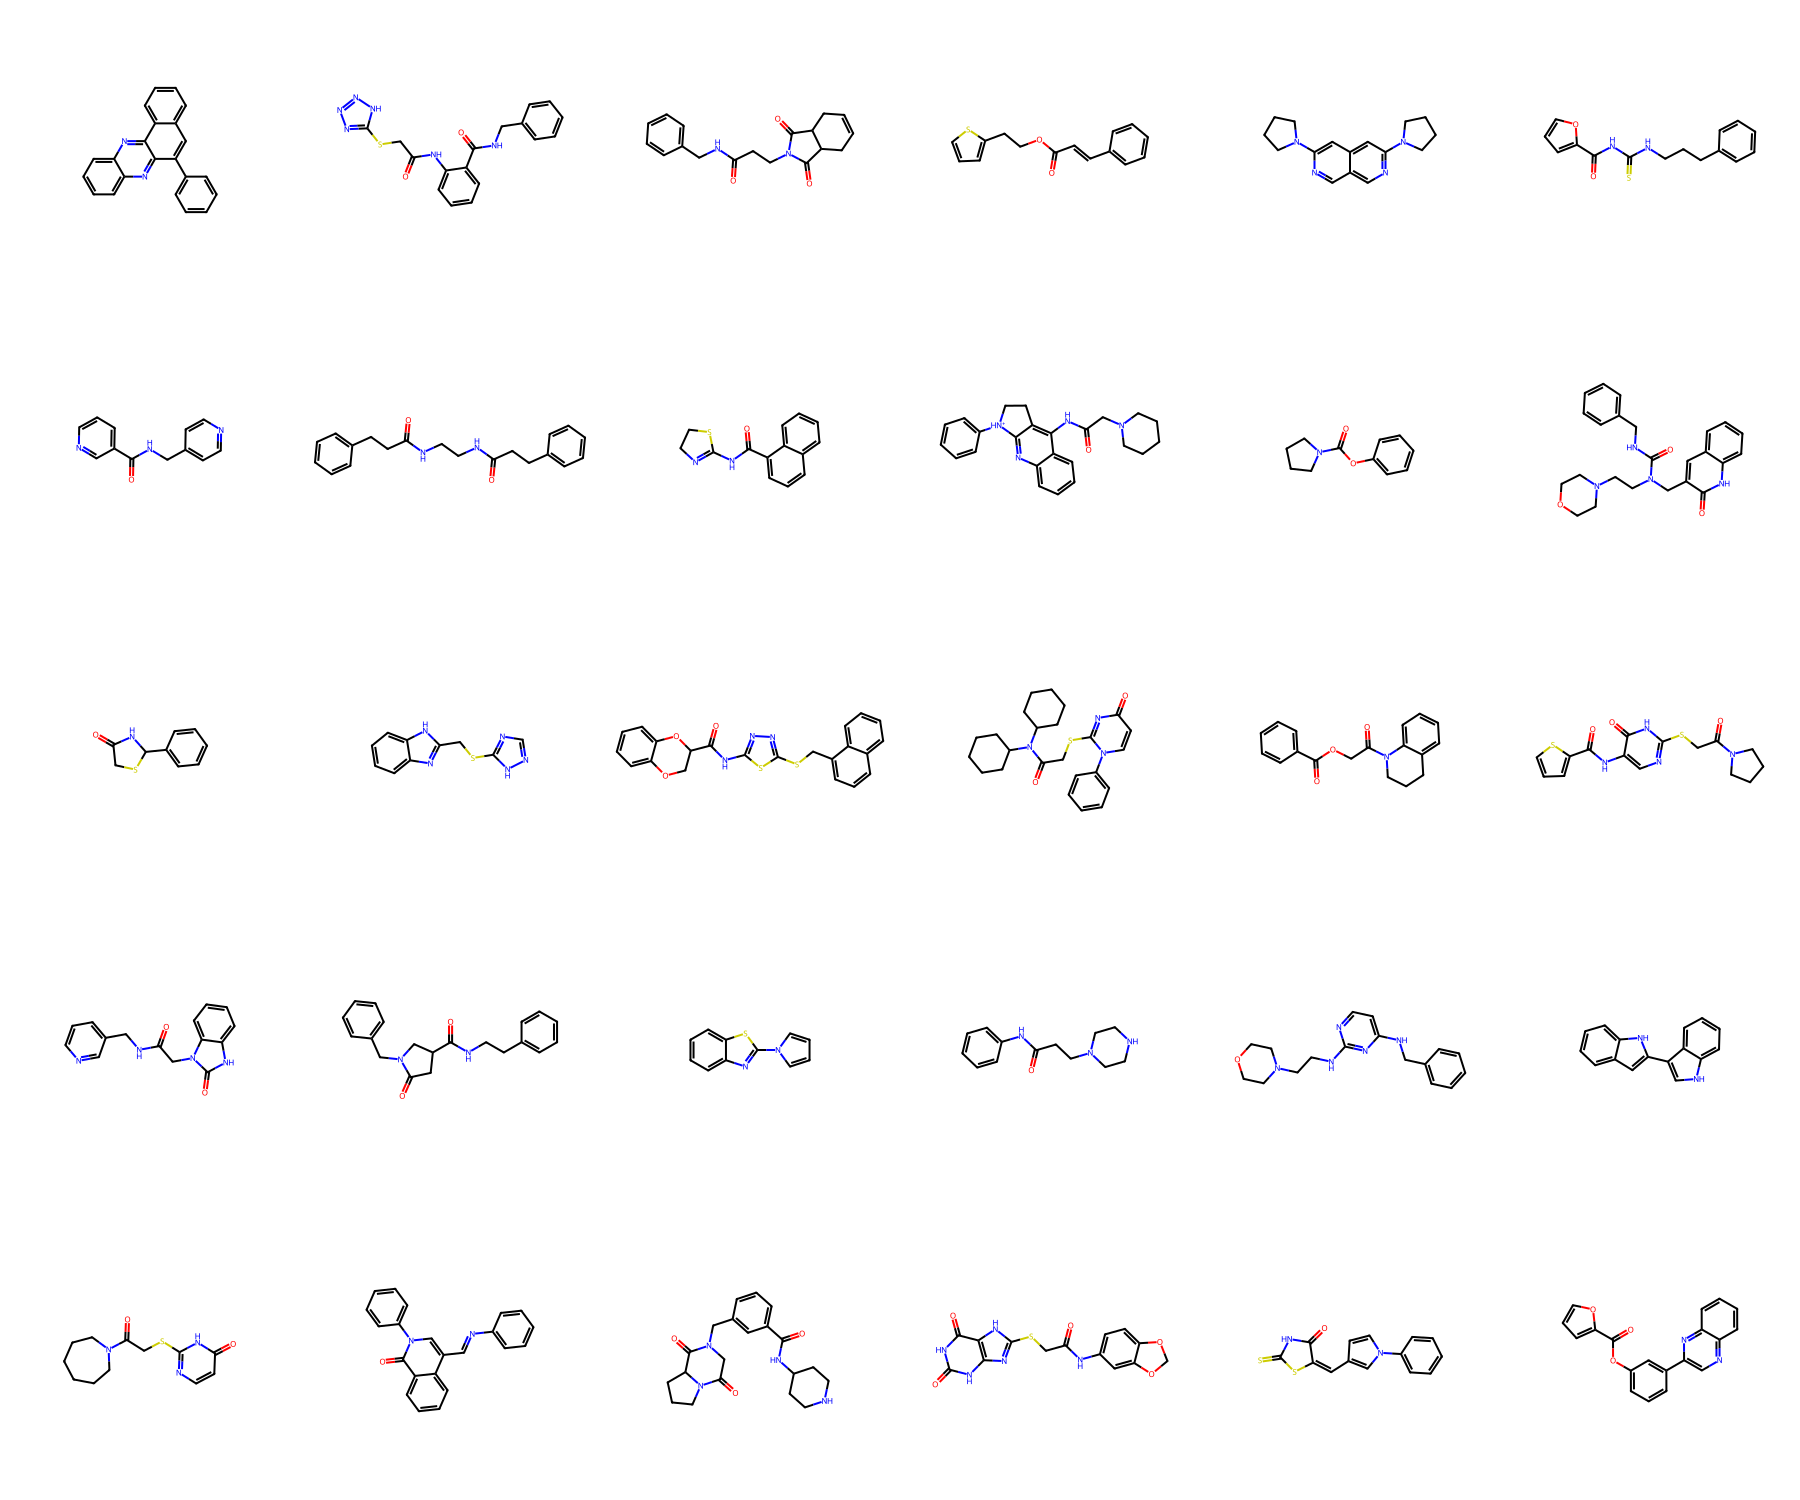

In [61]:
draw_mols_from_smiles(train_scaffold_sample)

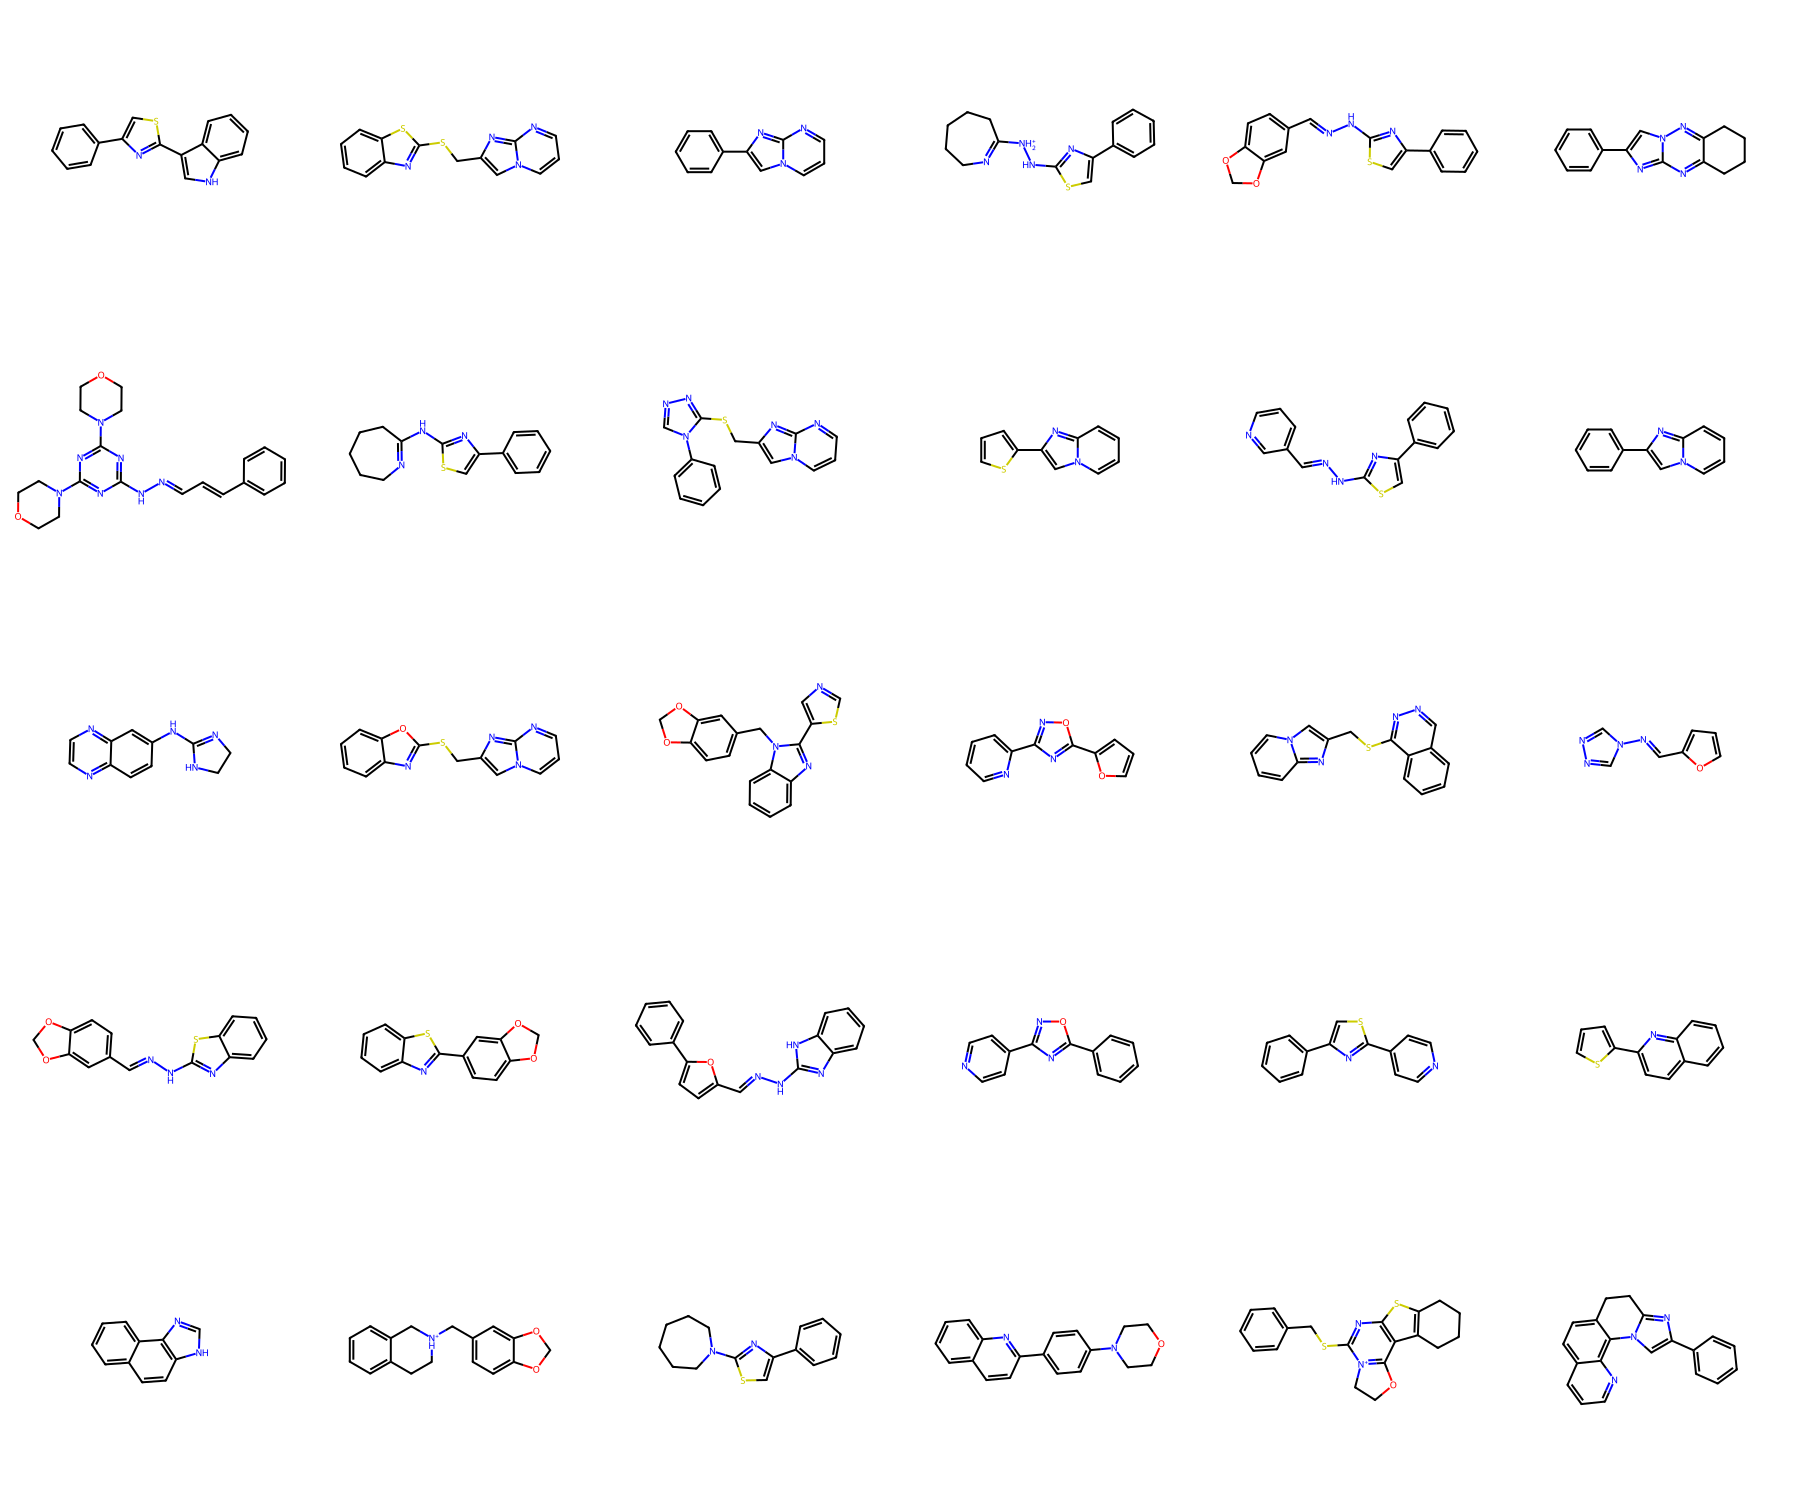

In [52]:
draw_mols_from_smiles(test_scaffold_sample)

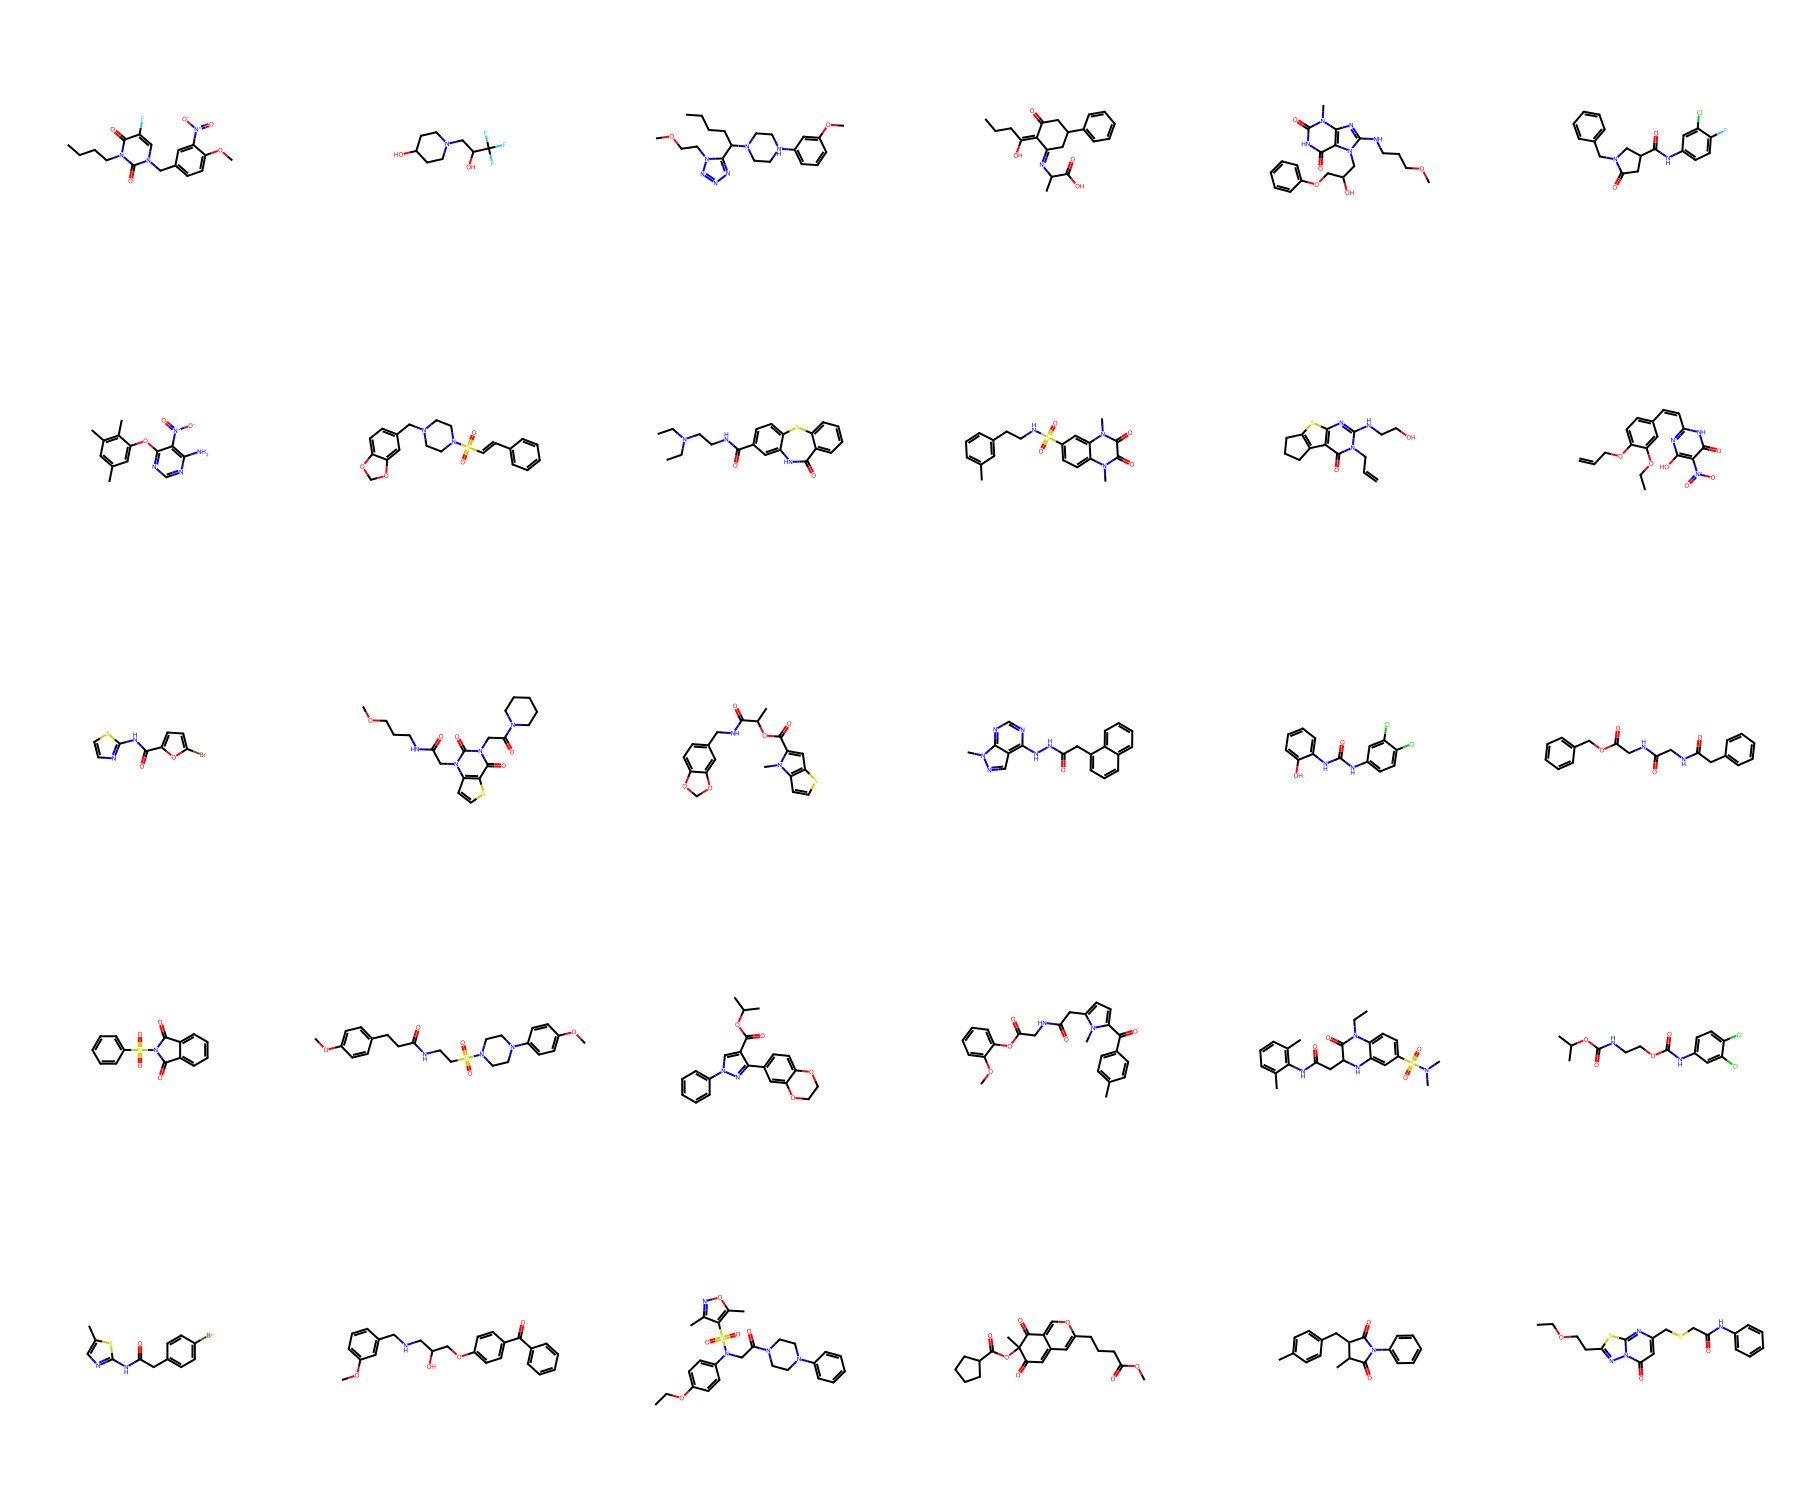

In [54]:
draw_mols_from_smiles(train_smiles_sample)

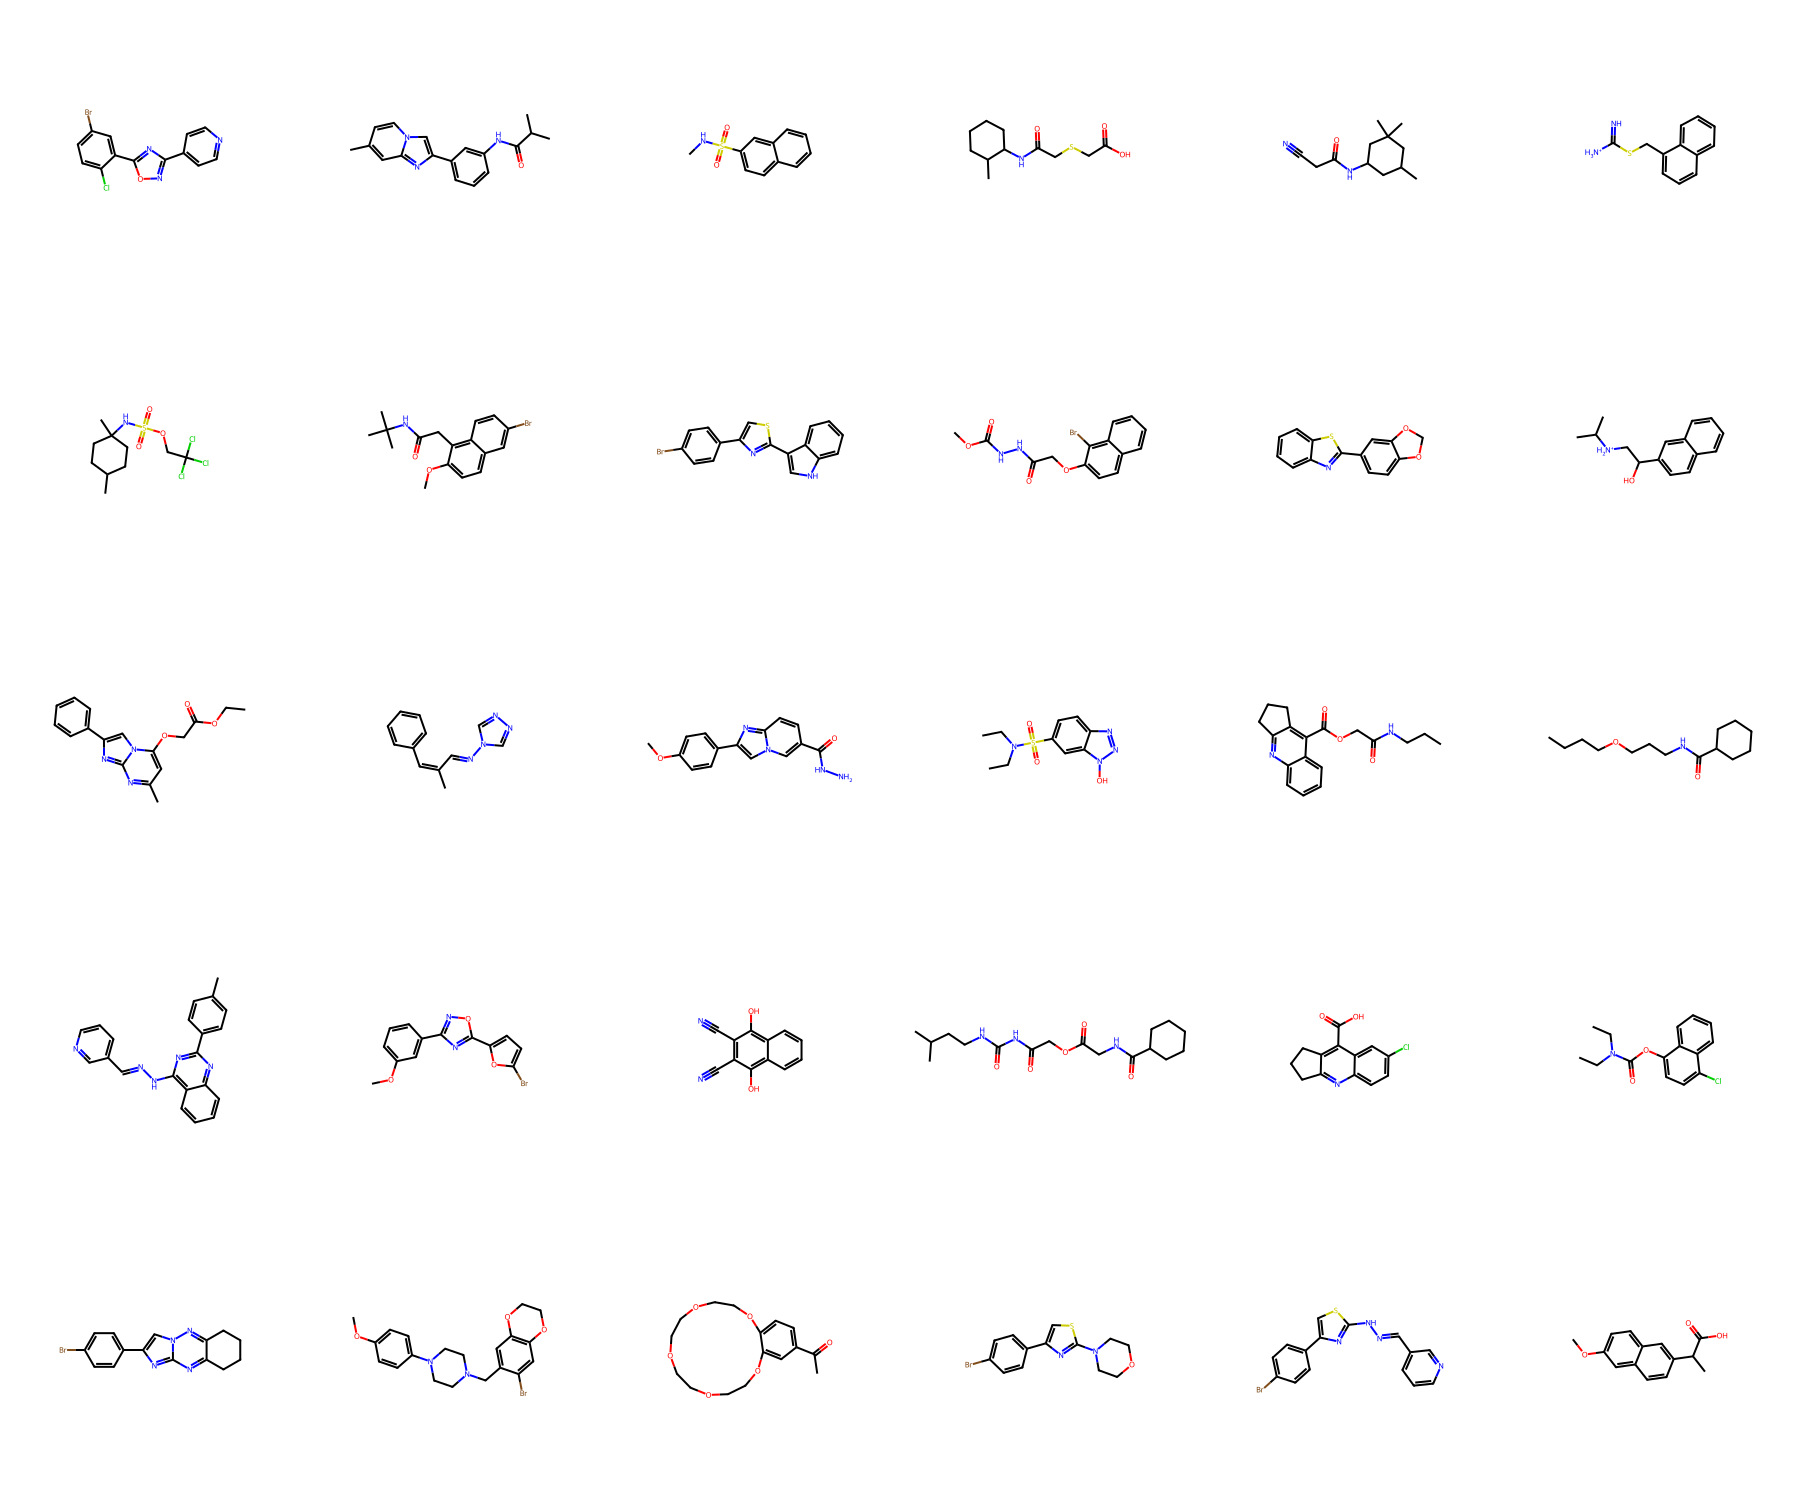

In [55]:
draw_mols_from_smiles(test_smiles_sample)

In [88]:
def get_scaffold_example(scaffold_sample, scaffold_to_smiles):
    scaffold_example = None
    for scaffold in scaffold_sample:
        num_smiles = len(scaffold_to_smiles[scaffold])
        if scaffold_example is None or num_smiles > len(scaffold_to_smiles[scaffold_example]):
            scaffold_example = scaffold
    return scaffold_example, scaffold_to_smiles[scaffold_example]
        
def draw_mols_with_scaffold(scaffold_smiles, smiles_list):
    n_cols = 5   # grid width

    # --- build mols ---
    top_mol = Chem.MolFromSmiles(scaffold_smiles)
    other_mols = [Chem.MolFromSmiles(s) for s in smiles_list]

    # --- pad first row so molecule is centered ---
    first_row = [None] * n_cols
    center_idx = (n_cols // 2)
    first_row[center_idx] = top_mol

    # --- combine all cells ---
    cells = first_row + other_mols

    # (optional) pad tail so last row is full width
    while len(cells) % n_cols != 0:
        cells.append(None)

    # --- draw ---
    img = Draw.MolsToGridImage(
        cells,
        molsPerRow=n_cols,
        subImgSize=(300, 300),
    )

    return img



test_scaffold_example, test_scaffold_smiles = get_scaffold_example(test_scaffold_sample, scaffold_to_smiles)
train_scaffold_example, train_scaffold_smiles = get_scaffold_example(train_scaffold_sample, scaffold_to_smiles)

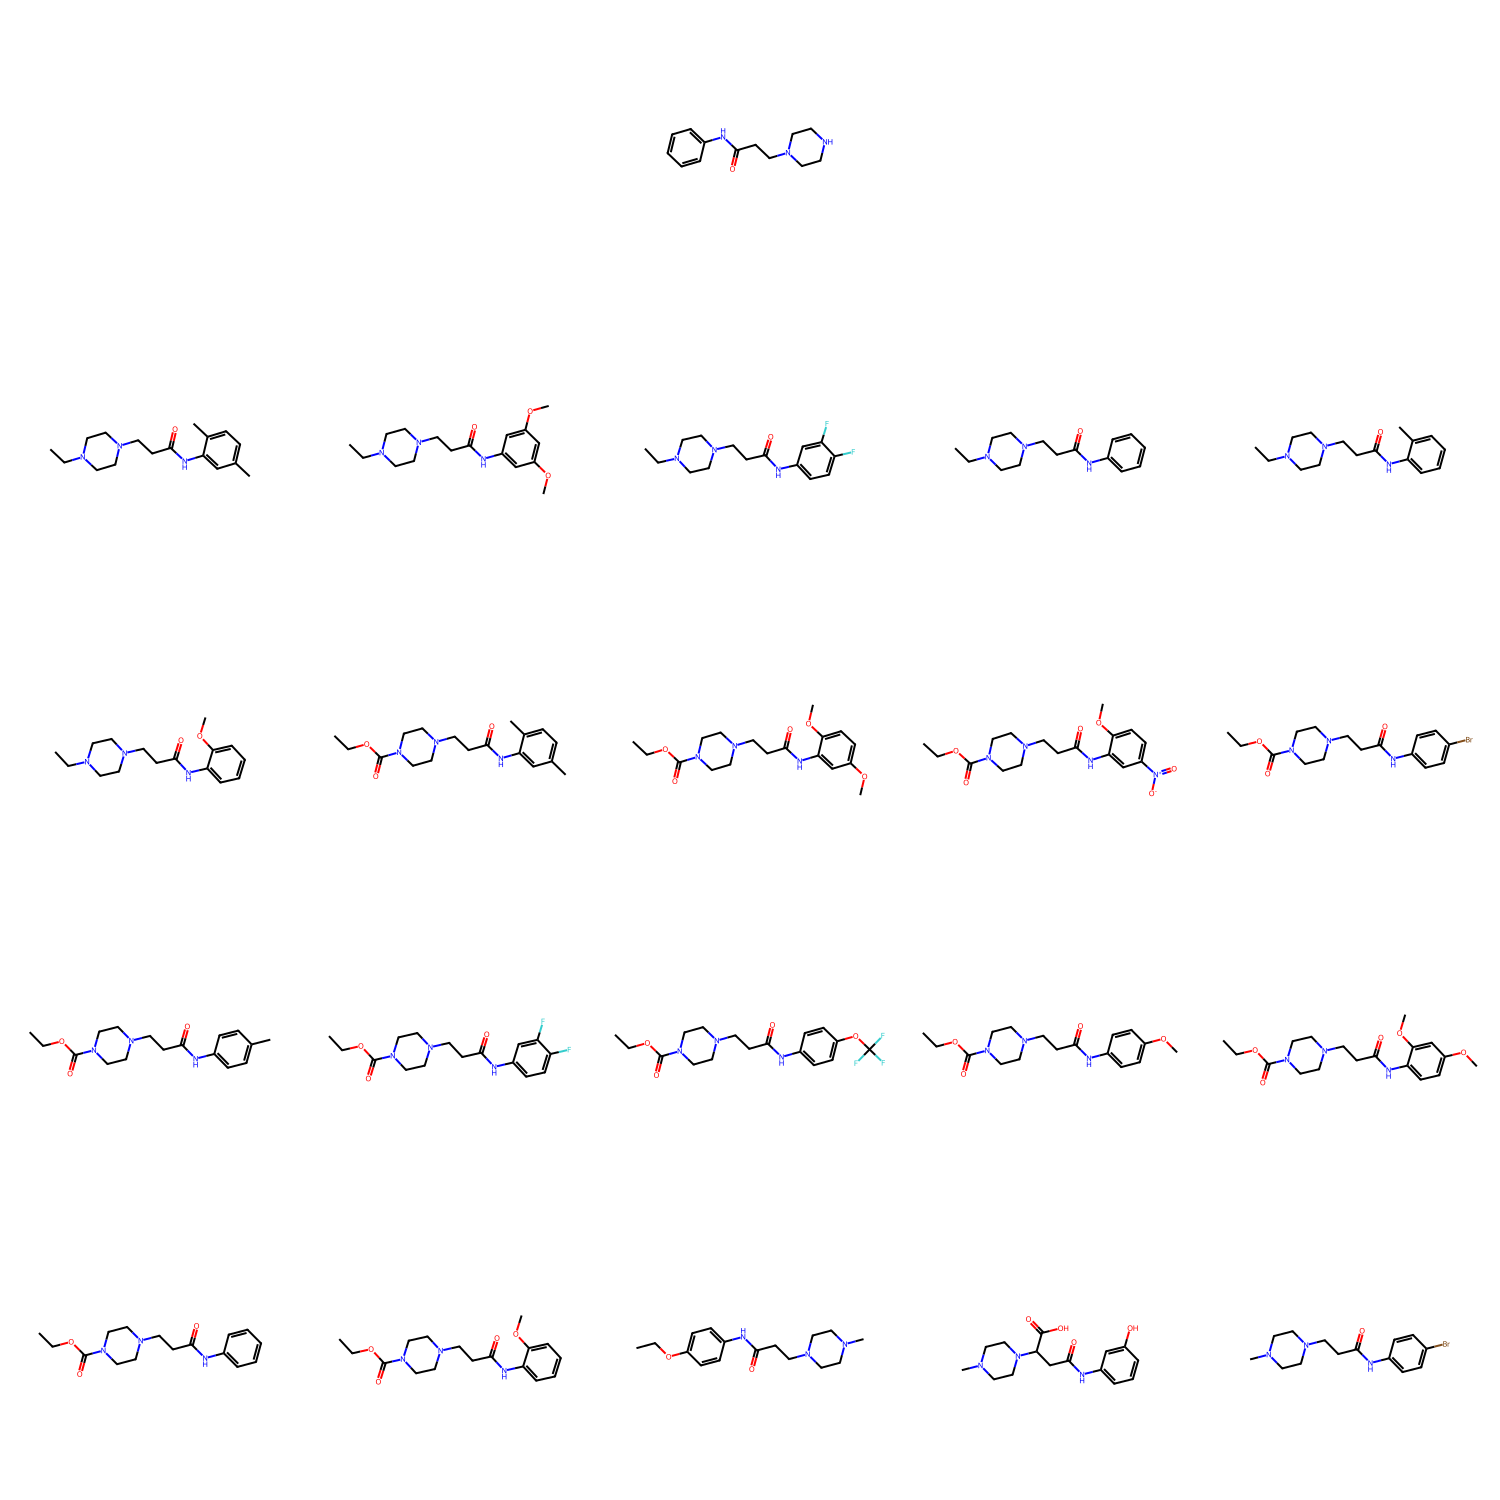

In [91]:
draw_mols_with_scaffold(train_scaffold_example, train_scaffold_smiles[:20])

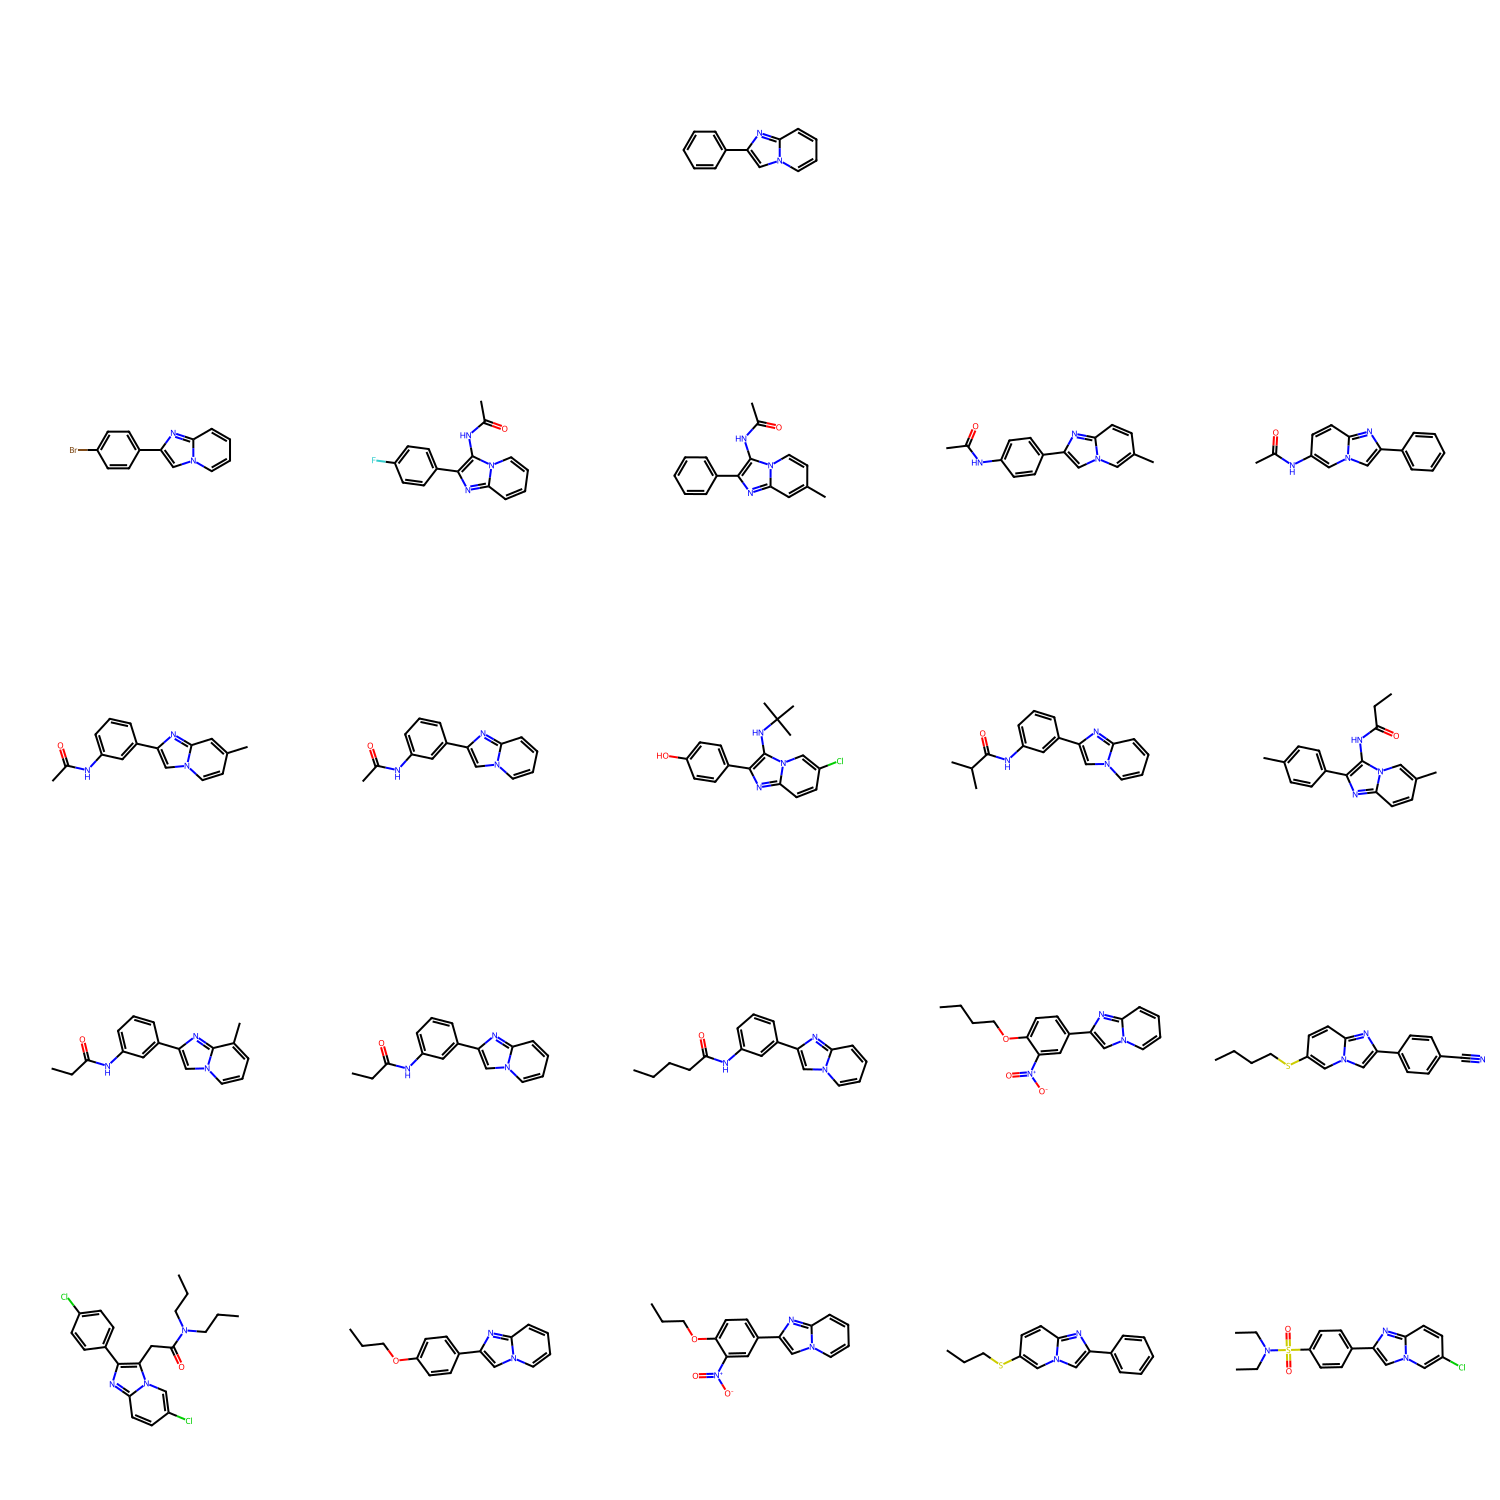

In [90]:
draw_mols_with_scaffold(test_scaffold_example, test_scaffold_smiles[:20])